In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
import optuna

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import KFold, cross_validate

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
df_train = pd.read_parquet("../data/processed/train_test_out_sample_cleaned/idf_vf_train_selected_features.parquet")
df_test = pd.read_parquet("../data/processed/train_test_out_sample_cleaned/idf_vf_test_selected_features.parquet")
df_oos = pd.read_parquet("../data/processed/train_test_out_sample_cleaned/idf_vf_out_of_sample_selected_features.parquet")

## RANDOM FOREST

In [18]:
# 1. Définition des colonnes à bannir de X
TARGET = 'prix_m2'
cols_to_ban = [
    TARGET,
    'code_departement'
]

# 2. Fonction pour créer X et y
def prepare_data(df, dataset_name):
    cols_to_drop = [c for c in cols_to_ban if c in df.columns]

    X = df.drop(columns=cols_to_drop)
    y = df[TARGET]

    print(f"[{dataset_name}]")
    print(f" -> Colonnes supprimées : {cols_to_drop}")
    print(f" -> Dimensions X : {X.shape} | y : {y.shape}")
    return X, y

# 3. Application
X_train, y_train = prepare_data(df_train, "TRAIN")
X_test, y_test   = prepare_data(df_test, "TEST")
X_oos, y_oos     = prepare_data(df_oos, "OOS")

[TRAIN]
 -> Colonnes supprimées : ['prix_m2', 'code_departement']
 -> Dimensions X : (469174, 22) | y : (469174,)
[TEST]
 -> Colonnes supprimées : ['prix_m2', 'code_departement']
 -> Dimensions X : (117294, 22) | y : (117294,)
[OOS]
 -> Colonnes supprimées : ['prix_m2', 'code_departement']
 -> Dimensions X : (47768, 22) | y : (47768,)


/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_1476/1797589386.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_1476/1797589386.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(


Dataset d'entraînement Total : (469174, 22)
Dataset OOS (Validation)     : (47768, 22)

[Sampling] Création de l'échantillon de 50000 lignes...
 -> Optuna travaillera sur : (50000, 22) (au lieu de (469174, 22))

[Optuna] Recherche des hyperparamètres (sur le sample)...


Best trial: 15. Best value: 1577.81: 100%|██████████| 20/20 [18:34<00:00, 55.74s/it]


 Optuna RF terminé !
 -> Meilleur RMSE (Sample) : 1577.81
 -> Meilleurs paramètres   : {'n_estimators': 364, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 0.8163529042860826}

[Final] Entraînement du modèle final sur TOUT le dataset (X_train)...

[Rapport] Comparaison des performances
  RÉSULTATS COMPARATIFS (RANDOM FOREST)  
Métrique     TRAIN      TEST  OOS (Validation)
    RMSE 1367.0083 1481.3134         1561.1956
     MAE  908.3049  969.0834         1041.7568
      R²    0.8174    0.7852            0.7407


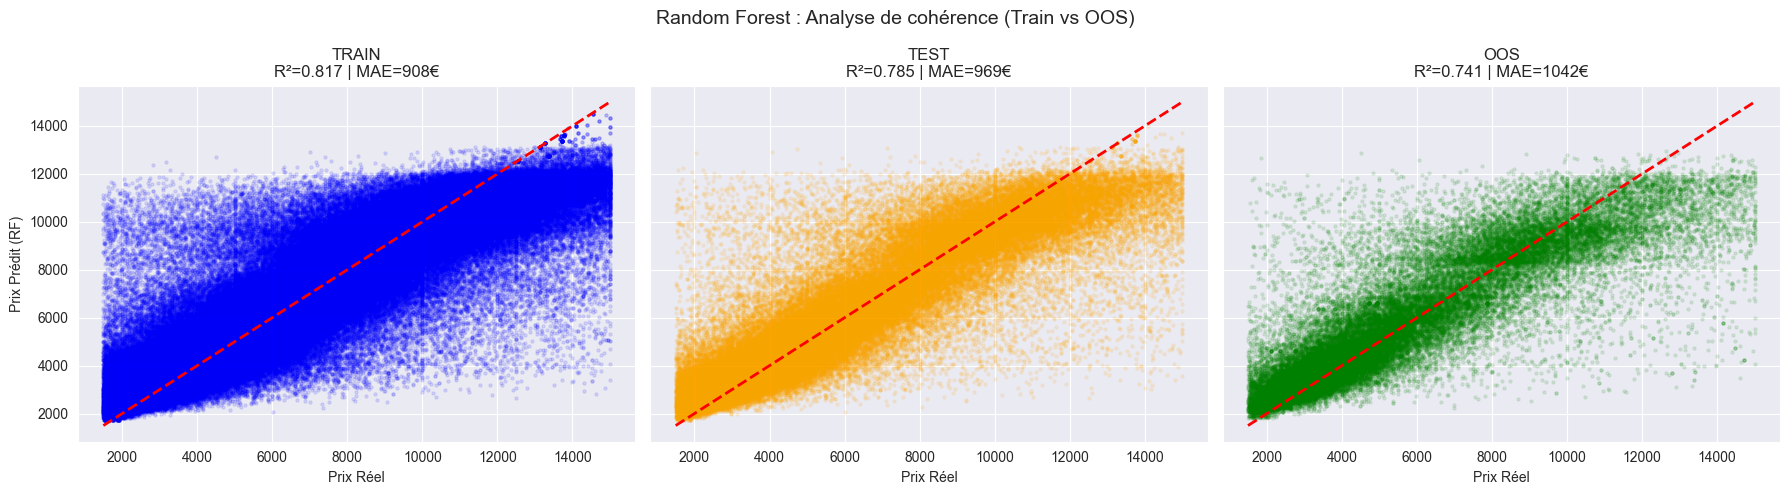

In [21]:
# Configuration
optuna.logging.set_verbosity(optuna.logging.WARNING)


print(f"Dataset d'entraînement Total : {X_train.shape}")
print(f"Dataset OOS (Validation)     : {X_oos.shape}")


target_sample_size_rf = 50000
frac_sample_rf = target_sample_size_rf / len(X_train)



def stratified_sample_rf(X, y, frac, bins=20, seed=42):
    # On recombine temporairement pour stratifier sur le prix
    df_tmp = pd.concat([X, y], axis=1)

    # Création des bins de prix
    df_tmp["_bin"] = pd.qcut(df_tmp[y.name], q=bins, duplicates="drop")

    # Sampling proportionnel dans chaque bin
    df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )

    return df_samp.drop(columns=[y.name, "_bin"]), df_samp[y.name]

print(f"\n[Sampling] Création de l'échantillon de {target_sample_size_rf} lignes...")

# On crée l'échantillon à partir du Train complet
X_sample_rf, y_sample_rf = stratified_sample_rf(X_train, y_train, frac=frac_sample_rf)

print(f" -> Optuna travaillera sur : {X_sample_rf.shape} (au lieu de {X_train.shape})")

# 2. OPTUNA

print("\n[Optuna] Recherche des hyperparamètres (sur le sample)...")

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 700),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 5, 25),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 4, 18),
        "max_features": trial.suggest_float("max_features", 0.4, 0.9)
    }

    model = RandomForestRegressor(
        n_jobs=-1,
        random_state=42,
        **params
    )

    #on gère les NaN
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', model)
    ])

    cv = KFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_validate(
        pipeline, X_sample_rf, y_sample_rf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'],
        cv=cv, n_jobs=-1
    )

    rmse = np.sqrt(-scores['test_neg_mean_squared_error'].mean())
    mae = -scores['test_neg_mean_absolute_error'].mean()

    trial.set_user_attr("mae", mae)
    return rmse

N_TRIALS_RF = 20
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=N_TRIALS_RF, show_progress_bar=True)

print(f" Optuna RF terminé !")
print(f" -> Meilleur RMSE (Sample) : {study_rf.best_value:.2f}")
print(f" -> Meilleurs paramètres   : {study_rf.best_params}")

best_params_rf = study_rf.best_params


# 3. ENTRAÎNEMENT FINAL (SUR TOUT LE TRAIN)

print("\n[Final] Entraînement du modèle final sur TOUT le dataset (X_train)...")

model_final_rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    verbose=0,
    **best_params_rf
)

# Pipeline final
pipe_final_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', model_final_rf)
])

# Fit sur le dataset COMPLET
pipe_final_rf.fit(X_train, y_train)


# 4. ÉVALUATION COMPARATIVE (TRAIN vs TEST vs OOS)

print("\n[Rapport] Comparaison des performances")

# Prédictions
y_pred_train = pipe_final_rf.predict(X_train)
y_pred_test  = pipe_final_rf.predict(X_test)
y_pred_oos   = pipe_final_rf.predict(X_oos)

def get_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [rmse, mae, r2]

scores_train = get_metrics(y_train, y_pred_train)
scores_test  = get_metrics(y_test, y_pred_test)
scores_oos   = get_metrics(y_oos, y_pred_oos)

df_results = pd.DataFrame({
    "Métrique": ["RMSE", "MAE", "R²"],
    "TRAIN": scores_train,
    "TEST": scores_test,
    "OOS (Validation)": scores_oos
}).round(4)

print("  RÉSULTATS COMPARATIFS (RANDOM FOREST)  ")

print(df_results.to_string(index=False))

#  VISUALISATION
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

datasets = [
    (y_train, y_pred_train, "TRAIN", "blue"),
    (y_test, y_pred_test, "TEST", "orange"),
    (y_oos, y_pred_oos, "OOS", "green")
]

for ax, (y_true, y_pred, title, color) in zip(axes, datasets):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5, c=color)
    min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_title(f"{title}\nR²={r2:.3f} | MAE={mae:.0f}€")
    ax.set_xlabel("Prix Réel")

axes[0].set_ylabel("Prix Prédit (RF)")
plt.suptitle("Random Forest : Analyse de cohérence (Train vs OOS)", fontsize=14)
plt.tight_layout()
plt.show()

## XGBOOST

Dataset d'entraînement Total : (469174, 22)
Dataset OOS                  : (47768, 22)

[Sampling] Création de l'échantillon de 50000 lignes...


/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_1476/38453982.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_1476/38453982.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(


 -> Optuna travaillera sur : (50000, 22) (au lieu de (469174, 22))

[Optuna] Recherche des hyperparamètres (sur le sample)...


Best trial: 2. Best value: 1555.71: 100%|██████████| 30/30 [18:08<00:00, 36.28s/it]


 Optuna terminé !
 -> Meilleur RMSE (Sample) : 1555.71
 -> Meilleurs paramètres   : {'n_estimators': 390, 'max_depth': 8, 'learning_rate': 0.026425011991838505, 'subsample': 0.9837233736144304, 'colsample_bytree': 0.6953099501090184, 'min_child_weight': 6, 'gamma': 2.0953581934378054, 'reg_alpha': 1.2471081757227687, 'reg_lambda': 0.24407794919390158}

[Final] Entraînement du modèle final sur TOUT le dataset (X_train)

[Rapport] Comparaison des performances...
   RAPPORT DE PERFORMANCES COMPARATIF (XGBOOST)  
Métrique     TRAIN      TEST       OOS
    RMSE 1436.0083 1480.0334 1540.1541
     MAE  940.4417  961.1199 1023.8677
      R²    0.7985    0.7856    0.7477


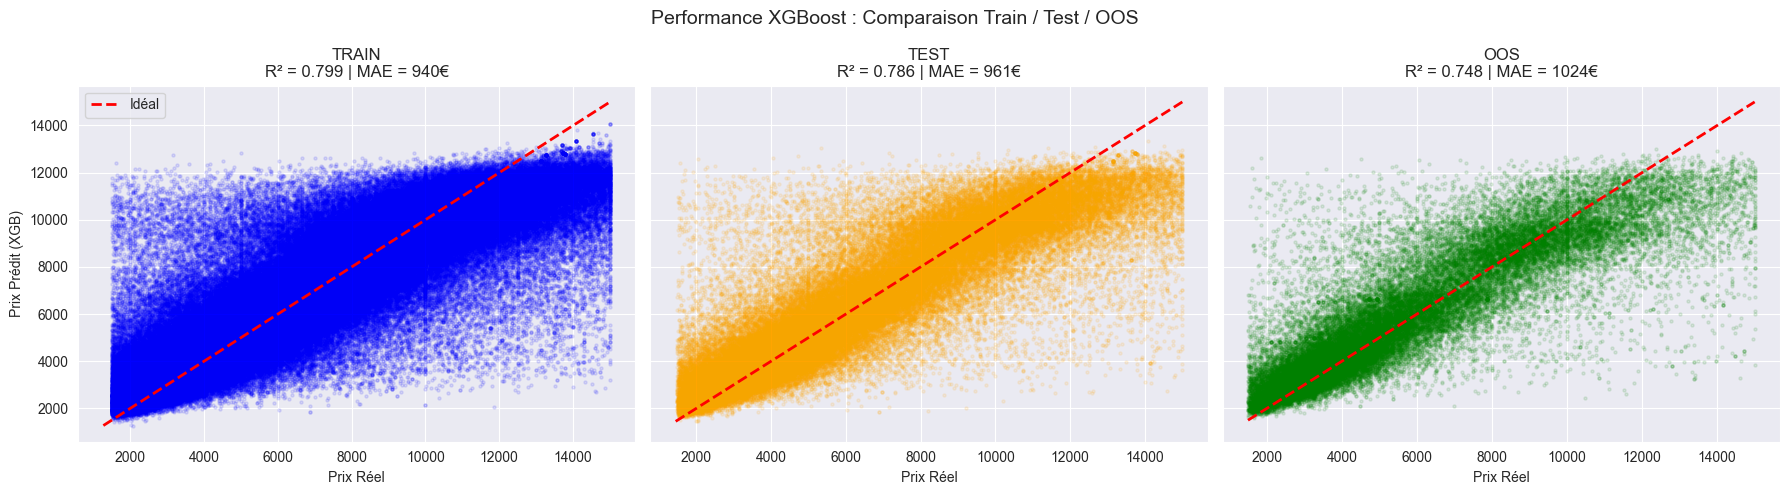


 DIAGNOSTIC 
Écart standard entre apprentissage et réalité (écart R² = 0.05).


In [20]:
# Configuration
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', None)

print(f"Dataset d'entraînement Total : {X_train.shape}")
print(f"Dataset OOS                  : {X_oos.shape}")


# 1. SAMPLING STRATIFIÉ

target_sample_size_xgb = 50000
frac_sample_xgb = target_sample_size_xgb / len(X_train)


def stratified_sample_xgb(X, y, frac, bins=20, seed=42):
    # On recombine temporairement pour stratifier sur le prix
    df_tmp = pd.concat([X, y], axis=1)

    # Création des bins de prix pour bien représenter toutes les gammes de prix
    df_tmp["_bin"] = pd.qcut(df_tmp[y.name], q=bins, duplicates="drop")

    # Sampling proportionnel
    df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )

    return df_samp.drop(columns=[y.name, "_bin"]), df_samp[y.name]

print(f"\n[Sampling] Création de l'échantillon de {target_sample_size_xgb} lignes...")

# Création du sample XGB
X_sample_xgb, y_sample_xgb = stratified_sample_xgb(X_train, y_train, frac=frac_sample_xgb)

print(f" -> Optuna travaillera sur : {X_sample_xgb.shape} (au lieu de {X_train.shape})")


# 2. OPTIMISATION BAYÉSIENNE (SUR L'ÉCHANTILLON)

print(f"\n[Optuna] Recherche des hyperparamètres (sur le sample)...")

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
    }

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42,
        verbosity=0,
        **params
    )

    # Cross-Validation
    cv = KFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_validate(
        model, X_sample_xgb, y_sample_xgb,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'],
        cv=cv, n_jobs=-1
    )

    rmse = np.sqrt(-scores['test_neg_mean_squared_error'].mean())
    mae = -scores['test_neg_mean_absolute_error'].mean()

    trial.set_user_attr("mae", mae)
    return rmse

N_TRIALS = 30
study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

print(f" Optuna terminé !")
print(f" -> Meilleur RMSE (Sample) : {study_xgb.best_value:.2f}")
print(f" -> Meilleurs paramètres   : {study_xgb.best_params}")

best_params_xgb = study_xgb.best_params


# 3. ENTRAÎNEMENT FINAL (SUR TOUT LE TRAIN)

print("\n[Final] Entraînement du modèle final sur TOUT le dataset (X_train)")

model_final_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42,
    **best_params_xgb
)

# Fit sur le dataset complet
model_final_xgb.fit(X_train, y_train)


# 4. ÉVALUATION COMPARATIVE (TRAIN vs TEST vs OOS)

print("\n[Rapport] Comparaison des performances...")

# Prédictions
y_pred_train = model_final_xgb.predict(X_train)
y_pred_test  = model_final_xgb.predict(X_test)
y_pred_oos   = model_final_xgb.predict(X_oos)

# Fonction de calcul des métriques
def get_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [rmse, mae, r2]

# Calcul
scores_train = get_metrics(y_train, y_pred_train)
scores_test  = get_metrics(y_test, y_pred_test)
scores_oos   = get_metrics(y_oos, y_pred_oos)

# Création du Tableau
df_results = pd.DataFrame({
    "Métrique": ["RMSE", "MAE", "R²"],
    "TRAIN": scores_train,
    "TEST": scores_test,
    "OOS": scores_oos
}).round(4)

print("   RAPPORT DE PERFORMANCES COMPARATIF (XGBOOST)  ")

print(df_results.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

datasets = [
    (y_train, y_pred_train, "TRAIN", "blue"),
    (y_test, y_pred_test, "TEST", "orange"),
    (y_oos, y_pred_oos, "OOS", "green")
]

for ax, (y_true, y_pred, title, color) in zip(axes, datasets):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5, c=color)

    # Ligne y=x
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Idéal")

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    ax.set_title(f"{title}\nR² = {r2:.3f} | MAE = {mae:.0f}€")
    ax.set_xlabel("Prix Réel")
    if title == "TRAIN":
        ax.legend()

axes[0].set_ylabel("Prix Prédit (XGB)")
plt.suptitle(f"Performance XGBoost : Comparaison Train / Test / OOS", fontsize=14)
plt.tight_layout()
plt.show()